In [1]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
import sklearn
import pickle
import itertools
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import pandas as pd
from skimage import measure
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage.morphology import binary_erosion, binary_dilation
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import csv
from functools import reduce
from sklearn.decomposition import PCA

In [2]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [3]:
fly_num=['226','227','228','234','239','240','241','242','249','250']
fly_num='250'
func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}/'
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
# Suppress RuntimeWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [4]:
###########################
### PREP VISUAL STIMULI ###
###########################

vision_path = os.path.join(func_path,'func_0', 'visual')

### Load Photodiode ###
t, ft_triggers, pd1, pd2 = brainsss.load_photodiode(vision_path)
stimulus_start_times = brainsss.extract_stim_times_from_pd(pd2, t)

# *100 puts in units of 10ms, which will match fictrac
st_10ms = [int(stimulus_start_times[i]*100) for i in range(len(stimulus_start_times))]

# get 1ms version to match neural timestamps
st_ms= [i*10 for i in st_10ms]
starts_loom = st_10ms

loading photodiode data... done


In [5]:
####################
### Prep Fictrac ###
####################

fictrac_path = os.path.join(func_path, 'func_0', 'fictrac')
fictrac_raw = brainsss.load_fictrac(fictrac_path)

fps = 100
resolution = 10 #desired resolution in ms
expt_len = fictrac_raw.shape[0]/fps*1000
behaviors = ['dRotLabY', 'dRotLabZ', 'dRotLabX', 'speed']
fictrac = {}
for behavior in behaviors:
    if behavior == 'dRotLabY': short = 'Y'
    elif behavior == 'dRotLabZ': short = 'Z'
    elif behavior == 'dRotLabX': short = 'X'
    fictrac[short] = brainsss.smooth_and_interp_fictrac(fictrac_raw, fps, resolution, expt_len, behavior)
fictrac_timestamps = np.arange(0,expt_len,resolution)

In [6]:
rainbow_color=np.asarray(['#FFFFFF','#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93','#6d0d25'])[::-1] #,  '#6d0d25'
cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list('cmap', rainbow_color)

In [7]:
# fig,ax=plt.subplots(figsize=(10,10))
# norm = colors.LogNorm()
# plt.hist2d(fictrac['Y'],fictrac['Z'],bins=500,cmap=cmap_rainbow,norm=norm, rasterized=True);
# ax.set_ylim(-400,400)
# ax.set_xlim(-10,10)
# # ax.set_ylabel('Rotation, deg/sec')
# # ax.set_xlabel('Forward, mm/sec')
# ax.set_xticks([])
# ax.set_yticks([])
# ax.axhline(0, linewidth=2, linestyle='--', color='k')
# ax.axvline(0, linewidth=2, linestyle='--', color='k')
# ax.spines['top'].set_visible(False);
# ax.spines['right'].set_visible(False);
# # cbar = plt.colorbar()
# # cbar.ax.tick_params(labelsize=30)
# # plt.savefig(os.path.join(save_dir,f'{fly_num}_2d_hist.png'), dpi=300, bbox_inches='tight');
# # plt.savefig(os.path.join(save_dir,f'{fly_num}_2d_hist.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [35]:
small_starts_loom= [x * 30 / 180000 for x in starts_loom]

29.166666666666668

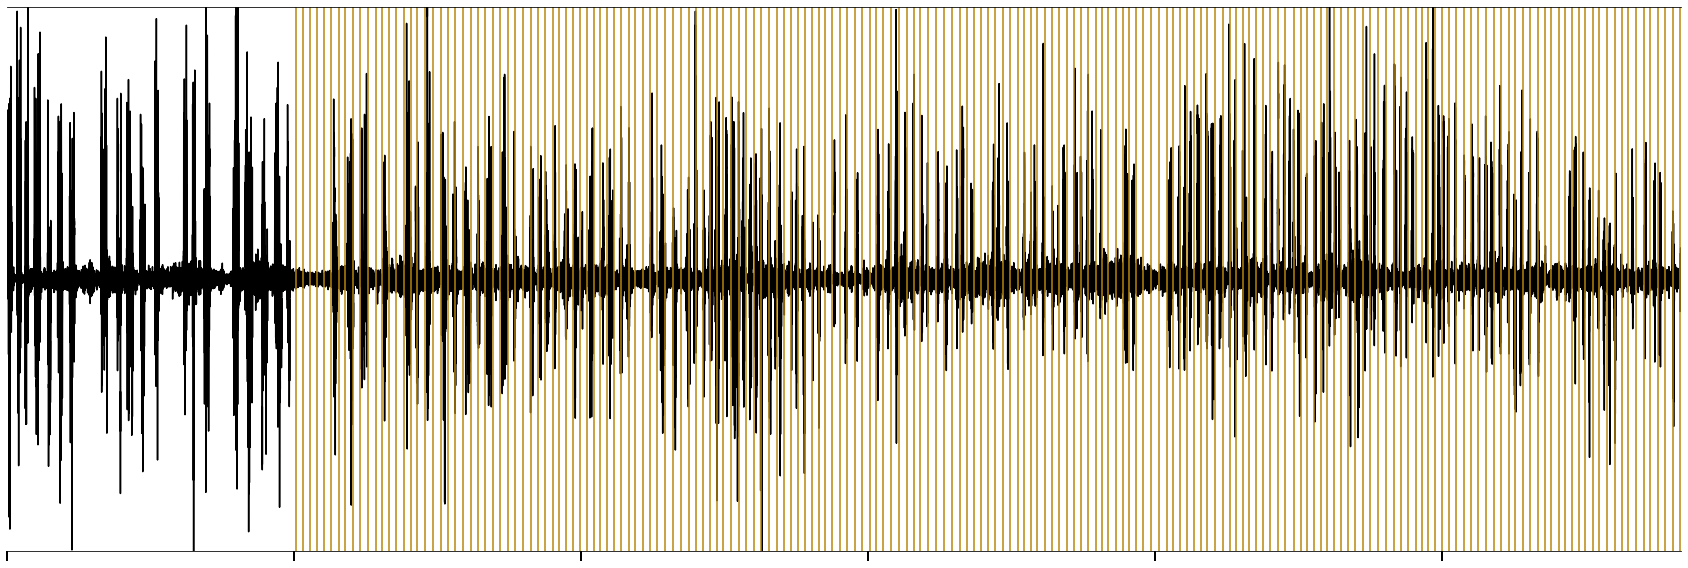

In [43]:
fig,ax=plt.subplots(figsize=(30,10))
time_min = np.linspace(0, 30, len(fictrac['Y']))
ax.plot(time_min,fictrac['Y'],color='k', rasterized=True)
ax.set_ylim(-15,15)
end=175000* 30 / 180000
ax.set_xlim(0,end)
ax.set_xticklabels([])
ax.set_yticks([])
# ax.tick_params(axis='x', labelsize=20) 
ax.spines['left'].set_visible(False);
ax.spines['right'].set_visible(False);
ax.tick_params(axis='x', length=10, width=2)
for i in range(len(small_starts_loom)):
    ax.axvline(small_starts_loom[i], color='#B8860B',rasterized=True)
# plt.savefig(os.path.join(save_dir,f'{fly_num}_trace_total.png'), dpi=300, bbox_inches='tight');
# plt.savefig(os.path.join(save_dir,f'{fly_num}_trace_total.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [86]:
fixed = (brainsss.load_fda_meanbrain()).numpy()
# masked = np.full_like(data, np.nan)
# mask = fixed_np > 0.1

226
Data shape is (314, 146, 91)
227
Data shape is (314, 146, 91)
228
Data shape is (314, 146, 91)
234
Data shape is (314, 146, 91)
239
Data shape is (314, 146, 91)
240
Data shape is (314, 146, 91)
241
Data shape is (314, 146, 91)
242
Data shape is (314, 146, 91)
249
Data shape is (314, 146, 91)
250
Data shape is (314, 146, 91)
CPU times: user 5.23 s, sys: 1min 31s, total: 1min 37s
Wall time: 36min 55s


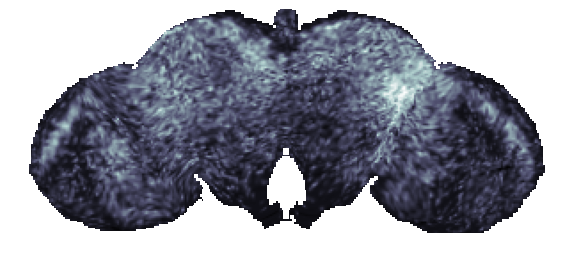

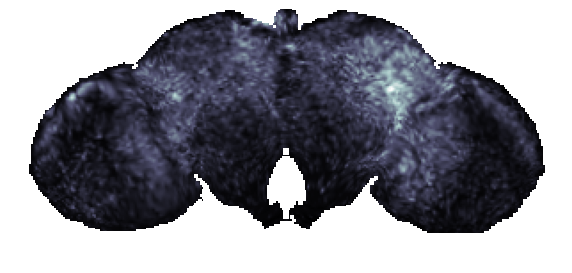

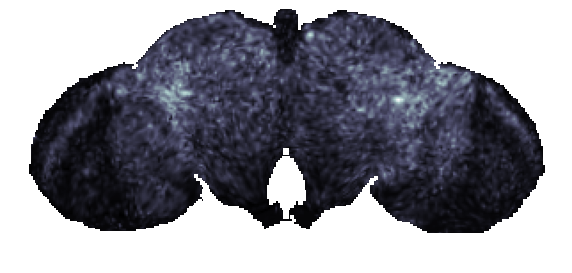

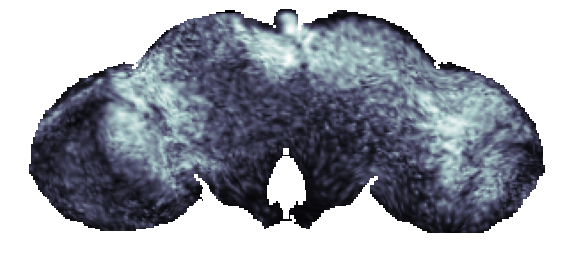

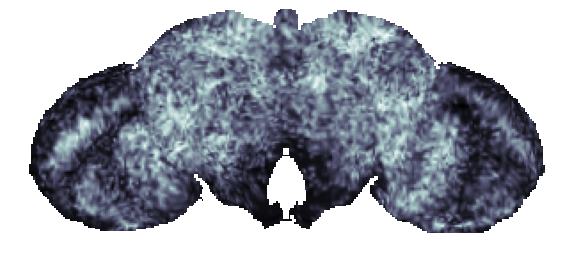

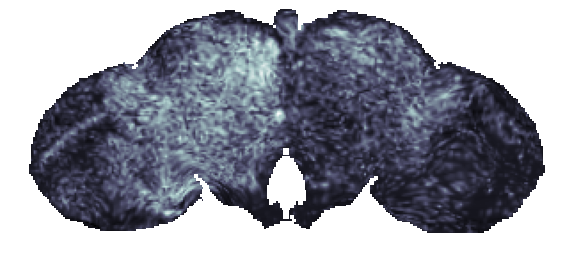

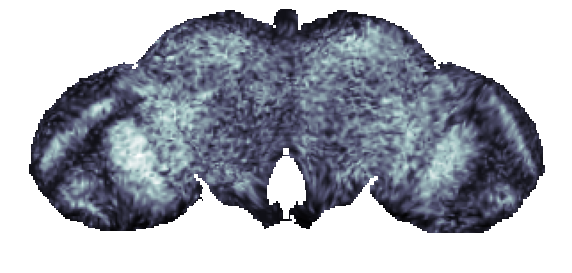

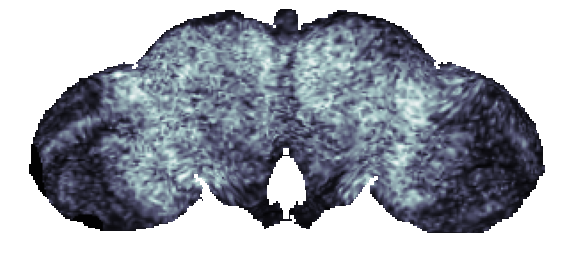

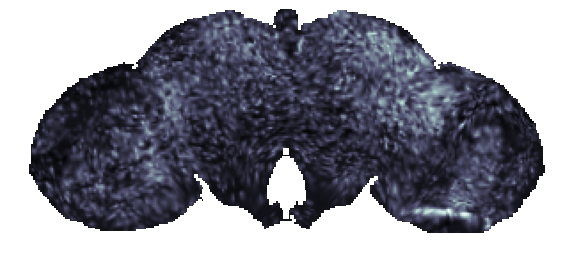

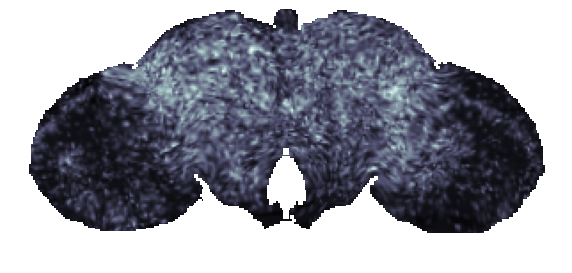

In [87]:
%%time
fly_num=['226','227','228','234','239','240','241','242','249','250']
for fly in fly_num:
    print(fly)
# fly=242
    func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly}/'
    warp_directory = os.path.join(func_path,'warp/functional_channel_2_moco_warp.h5')
    with h5py.File(warp_directory, 'r') as hf:
            tp=1000
            data = hf['data'][...,tp]
            dims = np.shape(data)
            print(f"Data shape is {dims}")
            masked=np.where(fixed>0.1,data, np.nan)
            fig,ax=plt.subplots(figsize=(10,10));
            ax.imshow(masked[:,:,27].T, cmap='bone');
            ax.axis('off');
#             plt.savefig(os.path.join(save_dir,f'{fly}_brain_{tp}.png'), dpi=300, bbox_inches='tight');
#             plt.savefig(os.path.join(save_dir,f'{fly}_brain_{tp}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True);

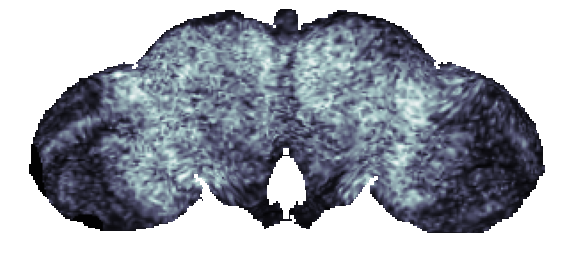

In [28]:
fig,ax=plt.subplots(figsize=(10,10));
ax.imshow(masked[:,:,27,1000].T, cmap='bone');
ax.axis('off');
# plt.savefig(os.path.join(save_dir,f'{fly}_brain_{tp}.png'), dpi=300, bbox_inches='tight');

In [ ]:
os.listdir(os.path.join(func_path,'func_0'))

226
227
228
234
239
240
241
242
249
250


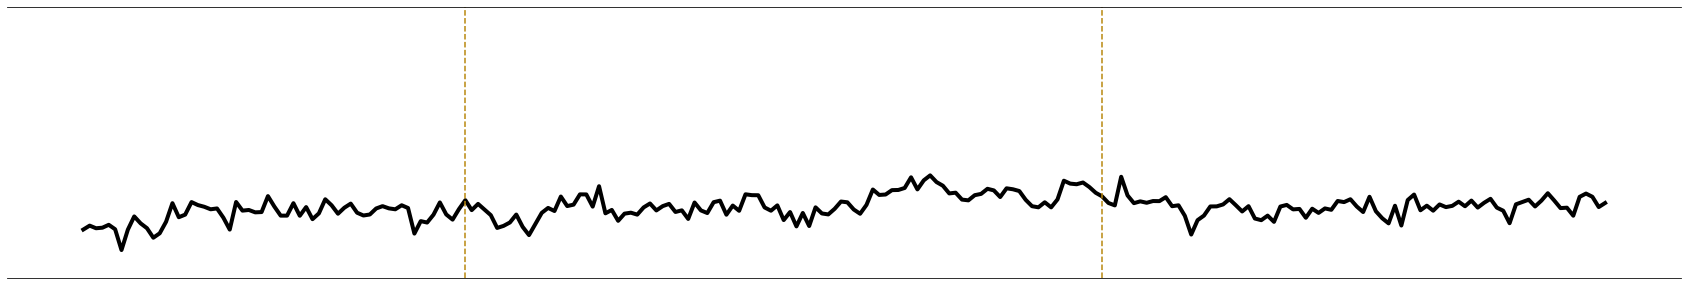

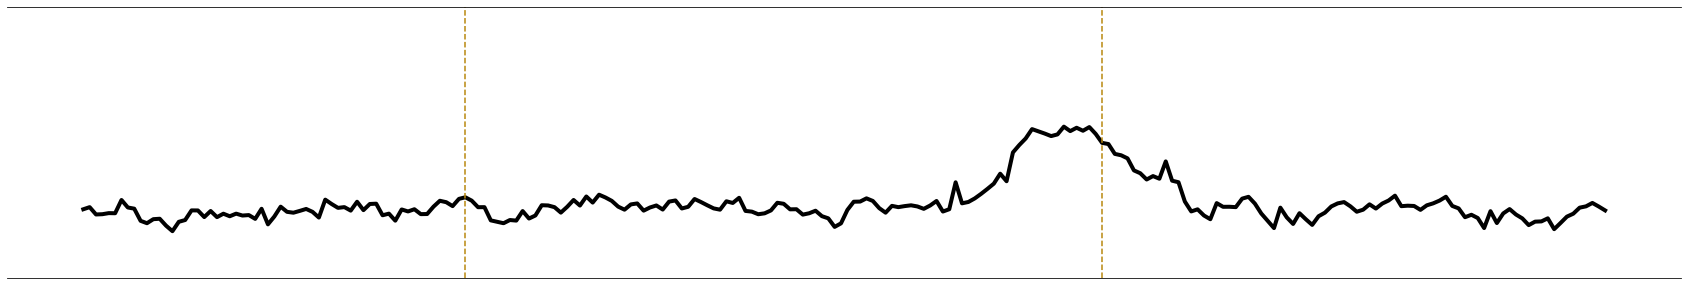

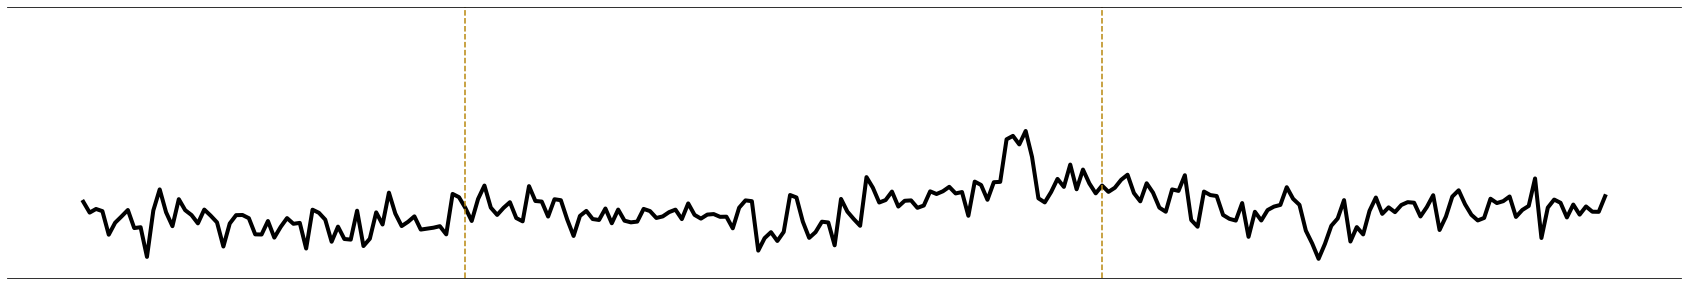

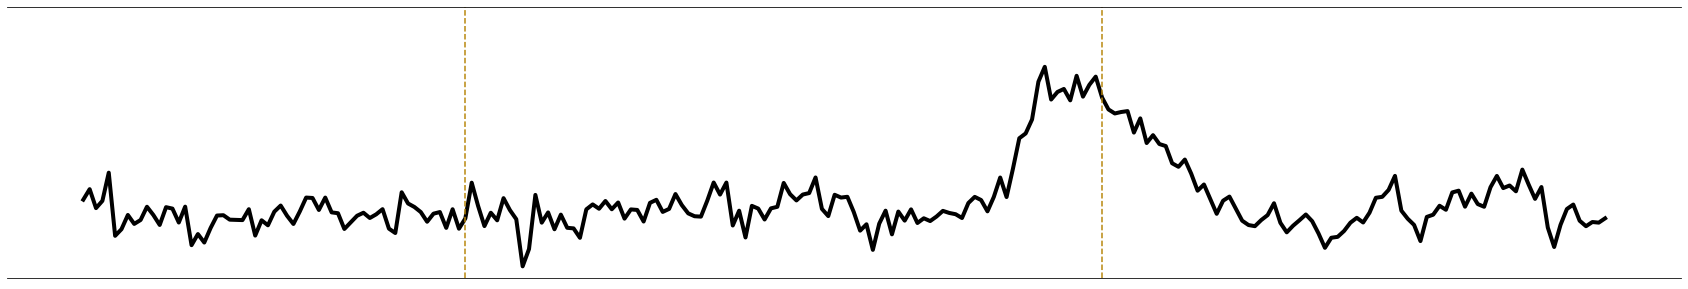

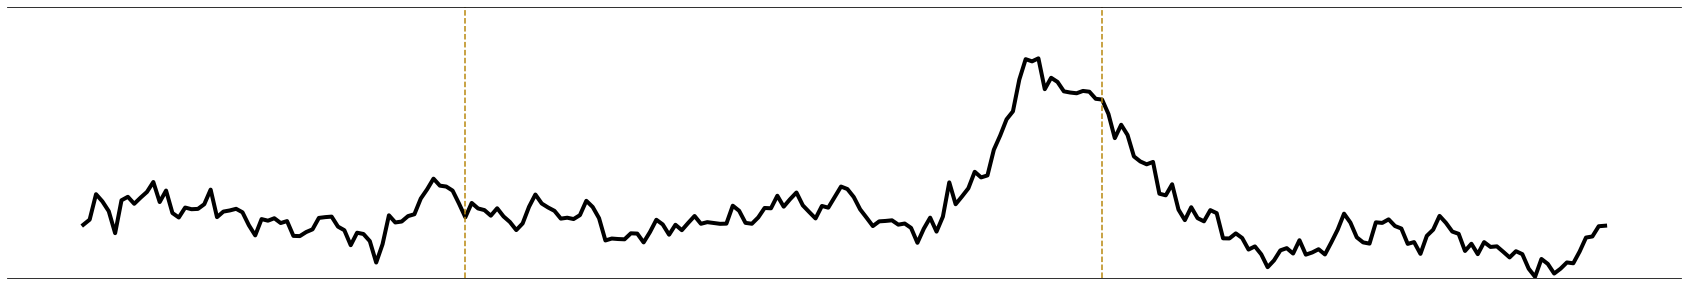

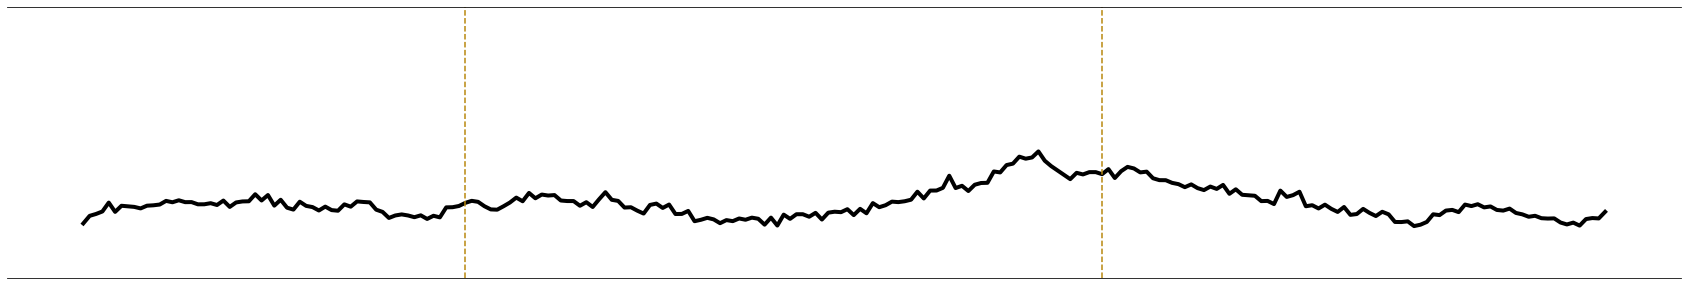

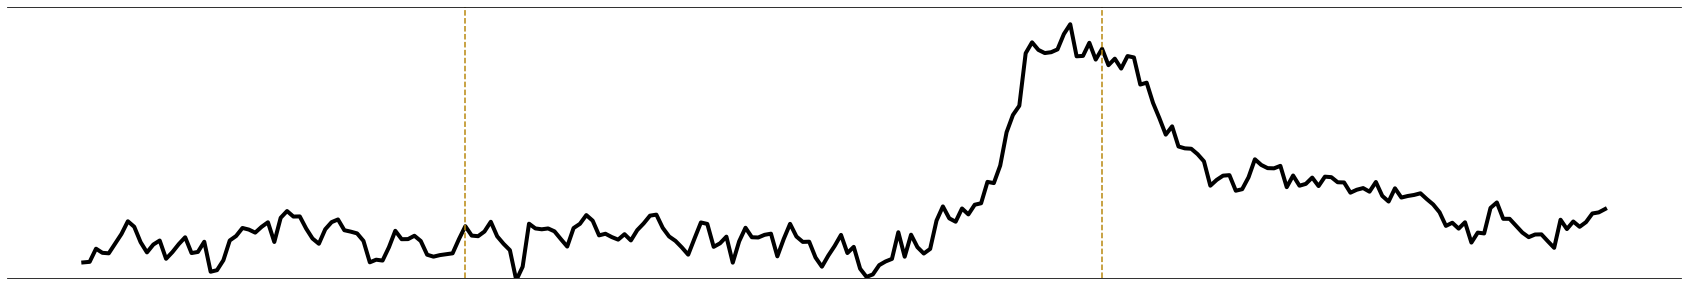

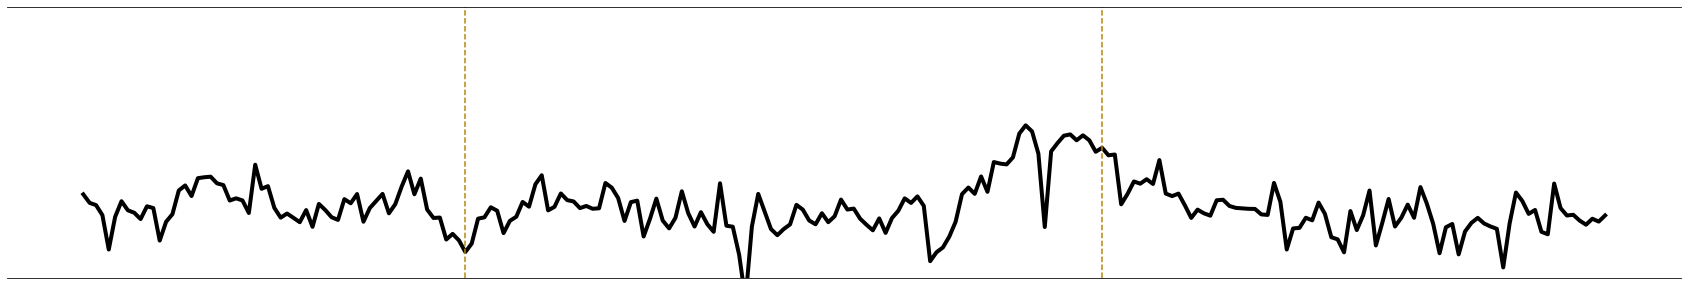

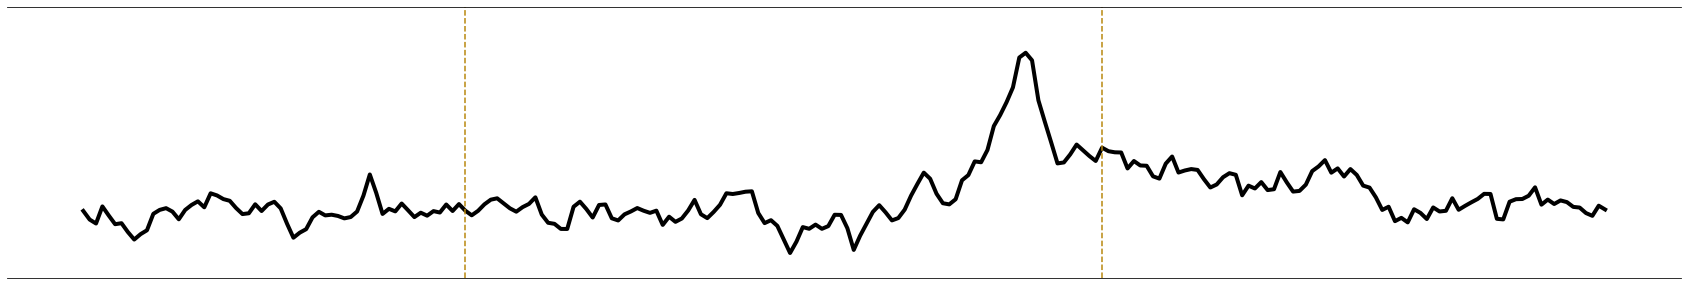

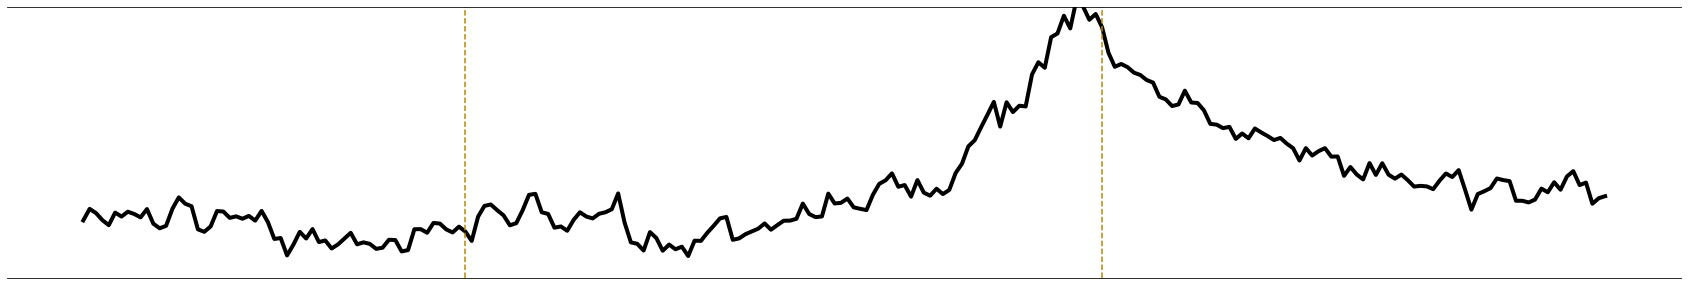

In [88]:
fly_num=['226','227','228','234','239','240','241','242','249','250']
ss=10
for fly in fly_num:
    print(fly)
# fly=228
    ind_directory = os.path.join(later_dir,f'single_fly_supervox/{fly}_stepsize_{ss}_STA.h5')
    with h5py.File(ind_directory, 'r') as hf:
            data = hf['data']

            STA=np.moveaxis(data,0,-1)
            STA_flat=STA.reshape(-1,240)
            STA_flat[STA_flat>5]=5
            fig,ax=plt.subplots(figsize=(30,5))
            ax.plot(np.mean(STA_flat,axis=0),color='k',lw=4);
            ax.set_xticks([])
            ax.set_ylim(-2e-5,6e-5)
            ax.set_yticks([])
            ax.spines['left'].set_visible(False);
            ax.spines['right'].set_visible(False);
            ax.axvline(60, ls='--',color='#B8860B')
            ax.axvline(160,ls='--', color='#B8860B')

        
#             plt.savefig(os.path.join(save_dir,f'{fly}_func_trace.png'), dpi=300, bbox_inches='tight');
#             plt.savefig(os.path.join(save_dir,f'{fly}_func_trace.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True);